In [72]:
# ============================================================
# REAL ESTATE RENTAL INCOME AND ROI ANALYSIS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Investment Assumptions

The rental-property analysis is based on a total investment budget of:
$5,000,000

### Financing Assumptions

| Assumption | Value |
|---|---:|
| Investor mortgage rate | 7.40% |
| Loan term | 30 years |

### Acquisition and Renovation Costs

| Assumption | Value |
|---|---:|
| Renovation cost | 8.00% of property value |
| Closing cost | 3.00% of property value |
| Minimum cash reserve | 2.00% of property value |

### Rental Assumptions

| Assumption | Value |
|---|---:|
| Expected rent increase after renovation | 10.00% |
| Vacancy rate | 7.30% |
| National single-family monthly rent | $2,314 |


### Operating-Expense Assumptions

| Assumption | Value |
|---|---:|
| Property management | 8.00% of collected rent |
| Maintenance | 5.00% of collected rent |
| Capital-expenditure reserve | 5.00% of collected rent |
| Property insurance | 0.60% of property value annually |

### Tax Assumptions

| Assumption | Value |
|---|---:|
| Default annual property-tax rate | 1.00% |
| Illustrative income-tax rate | 29.00% |

### Depreciation Assumptions

| Assumption | Value |
|---|---:|
| Depreciable building share | 80.00% of purchase price |
| Residential depreciation period | 27.5 years |

$$
\text{Annual Cash-Flow ROI}
=
\frac{\text{Monthly After-Tax Cash Flow} \times 12}{\$5{,}000{,}000}
\times 100
$$

### Property-Tax Calculation

Annual property taxes are estimated using:

$$
\text{Annual Property Tax}
=
\text{Property Value}
\times
\text{Property-Tax Rate}
$$

Monthly property taxes are calculated as:

$$
\text{Monthly Property Tax}
=
\frac{
\text{Property Value}
\times
\text{Property-Tax Rate}
}{12}
$$

For example, a $300,000 property in Minnesota, where the assumed property-tax rate is 1.00%, would have estimated annual property taxes of:

$$
\$300{,}000 \times 0.01 = \$3{,}000
$$

The corresponding estimated monthly property tax is:

$$
\frac{\$3{,}000}{12} = \$250
$$

### Fixed Monthly Mortgage payment Calculation

$$
M = \frac{P \cdot r(1+r)^n}{(1+r)^n - 1}
$$

Where:

- $M$ = monthly mortgage payment
- $P$ = loan principal
- $r$ = monthly interest rate
- $n$ = number of monthly payments

In [73]:
# ============================================================
# 2. DATASET FILENAMES
# ============================================================

RENT_FILENAME = "Metro_zori_uc_sfrcondomfr_sm_month.csv"

HOME_VALUE_FILENAME = (
    "Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
)

In [74]:
# ============================================================
# 3. STATE PROPERTY-TAX ASSUMPTIONS
# ============================================================

# Statewide effective property-tax percentages.
# These are screening estimates, not property-specific tax bills.

STATE_PROPERTY_TAX_PERCENT = {
    "NJ": 1.88,
    "IL": 1.88,
    "CT": 1.54,
    "VT": 1.51,
    "NH": 1.50,
    "NE": 1.44,
    "TX": 1.40,
    "OH": 1.36,
    "IA": 1.33,
    "WI": 1.32,
    "NY": 1.30,
    "PA": 1.26,
    "KS": 1.21,
    "MI": 1.19,
    "RI": 1.12,
    "MA": 1.00,
    "MN": 1.00,
    "SD": 1.00,
    "ME": 0.98,
    "AK": 0.94,
    "MD": 0.92,
    "ND": 0.92,
    "MO": 0.89,
    "OR": 0.81,
    "GA": 0.79,
    "OK": 0.79,
    "FL": 0.78,
    "VA": 0.78,
    "IN": 0.76,
    "WA": 0.75,
    "KY": 0.74,
    "CA": 0.70,
    "NC": 0.66,
    "NM": 0.63,
    "MT": 0.61,
    "DC": 0.60,
    "MS": 0.58,
    "AR": 0.56,
    "LA": 0.55,
    "DE": 0.54,
    "WY": 0.53,
    "TN": 0.52,
    "WV": 0.51,
    "NV": 0.50,
    "CO": 0.50,
    "ID": 0.50,
    "SC": 0.49,
    "AZ": 0.48,
    "UT": 0.48,
    "AL": 0.37,
    "HI": 0.29,
}

In [75]:
# ============================================================
# 4. LOCATE THE DATA FILES
# ============================================================

def locate_csv(filename, alternate_patterns=()):
    """
    Find a CSV file in common notebook and upload directories.
    """

    search_directories = [
        Path.cwd(),
        Path.cwd() / "upload",
        Path.cwd() / "tmp" / "roi_source",
    ]

    for directory in search_directories:
        candidate = directory / filename

        if candidate.is_file():
            return candidate

    for directory in search_directories:
        if not directory.is_dir():
            continue

        for pattern in alternate_patterns:
            matches = sorted(directory.glob(pattern))

            if matches:
                return matches[0]

    raise FileNotFoundError(
        f"Unable to locate {filename!r}. "
        "Place the dataset in your notebook folder or update the filename."
    )


rent_path = locate_csv(
    RENT_FILENAME,
    alternate_patterns=["*zori*.csv"],
)

home_value_path = locate_csv(
    HOME_VALUE_FILENAME,
    alternate_patterns=["*zhvi*.csv", "QA1*.csv"],
)

print("Rental dataset:", rent_path)
print("Home-value dataset:", home_value_path)

Rental dataset: C:\Users\HP\Metro_zori_uc_sfrcondomfr_sm_month.csv
Home-value dataset: C:\Users\HP\Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv


In [76]:
# ============================================================
# 5. LOAD THE DATA
# ============================================================

rent_df = pd.read_csv(
    rent_path,
    low_memory=False,
)

home_df = pd.read_csv(
    home_value_path,
    low_memory=False,
)

print("\nRental dataset shape:", rent_df.shape)
print("Home-value dataset shape:", home_df.shape)


Rental dataset shape: (752, 144)
Home-value dataset shape: (895, 324)


In [77]:
# ============================================================
# 6. IDENTIFY THE MONTHLY DATE COLUMNS
# ============================================================

def get_date_columns(dataframe):
    """
    Identify and sort Zillow date columns.
    """

    parsed_dates = pd.to_datetime(
        dataframe.columns,
        format="%Y-%m-%d",
        errors="coerce",
    )

    date_columns = [
        column
        for column, parsed_date in zip(
            dataframe.columns,
            parsed_dates,
        )
        if pd.notna(parsed_date)
    ]

    return sorted(
        date_columns,
        key=pd.to_datetime,
    )


rent_date_columns = get_date_columns(rent_df)
home_date_columns = get_date_columns(home_df)

latest_rent_date = rent_date_columns[-1]
latest_home_value_date = home_date_columns[-1]

print("\nLatest rental-data month:", latest_rent_date)
print("Latest home-value month:", latest_home_value_date)


Latest rental-data month: 2026-07-31
Latest home-value month: 2026-07-31


In [78]:
# ============================================================
# 7. PREPARE AND MERGE THE DATASETS
# ============================================================

rent_data = rent_df[
    [
        "RegionID",
        "SizeRank",
        "RegionName",
        "RegionType",
        "StateName",
        latest_rent_date,
    ]
].copy()

rent_data = rent_data.rename(
    columns={
        latest_rent_date: "Market Rent",
    }
)

home_data = home_df[
    [
        "RegionID",
        latest_home_value_date,
    ]
].copy()

home_data = home_data.rename(
    columns={
        latest_home_value_date: "Home Value",
    }
)

market_data = rent_data.merge(
    home_data,
    on="RegionID",
    how="inner",
    validate="one_to_one",
)

market_data = market_data.dropna(
    subset=[
        "Market Rent",
        "Home Value",
    ]
)

market_data = market_data[
    (market_data["Market Rent"] > 0)
    & (market_data["Home Value"] > 0)
].copy()

matched_metros = (
    market_data["RegionType"] == "msa"
).sum()

print("\nMatched metro areas:", matched_metros)



Matched metro areas: 737


### MORTGAGE PAYMENT FUNCTION

In [79]:
# ============================================================
# 8. MORTGAGE PAYMENT FUNCTION
# ============================================================

def mortgage_payment(
    principal,
    annual_interest_rate,
    loan_term_years=LOAN_TERM_YEARS,
):
    """
    Calculate a fixed monthly mortgage payment.

    Formula:

        M = P[r(1+r)^n] / [(1+r)^n - 1]

    Where:

        M = monthly mortgage payment
        P = loan principal
        r = monthly interest rate
        n = number of monthly payments
    """

    if principal <= 0:
        return 0.0

    monthly_rate = annual_interest_rate / 12

    number_of_payments = loan_term_years * 12

    if monthly_rate == 0:
        return principal / number_of_payments

    payment = (
        principal
        * monthly_rate
        / (
            1
            - (1 + monthly_rate) ** (-number_of_payments)
        )
    )

    return payment

# ============================================================
# 9. FIRST-YEAR INTEREST AND PRINCIPAL
# ============================================================

def first_year_interest_and_principal(
    principal,
    annual_interest_rate,
    monthly_payment,
):
    """
    Separate deductible mortgage interest from principal repayment.
    """

    if principal <= 0:
        return 0.0, 0.0

    monthly_rate = annual_interest_rate / 12

    if monthly_rate == 0:
        return 0.0, monthly_payment * 12

    ending_balance = (
        principal * (1 + monthly_rate) ** 12
        - monthly_payment
        * (
            (
                (1 + monthly_rate) ** 12 - 1
            )
            / monthly_rate
        )
    )

    principal_paid = principal - ending_balance

    interest_paid = (
        monthly_payment * 12
        - principal_paid
    )

    return interest_paid, principal_paid

### PORTFOLIO CASH-FLOW AND ROI FUNCTION

In [61]:
# ============================================================
# 10. PORTFOLIO CASH-FLOW AND ROI FUNCTION
# ============================================================

def calculate_portfolio(
    home_value,
    market_rent,
    state=None,
    down_payment=0.25,
):
    """
    Estimate rental cash flow and annual ROI for a $5 million portfolio.
    """

    home_value = float(home_value)
    market_rent = float(market_rent)

    # --------------------------------------------------------
    # Property tax
    # --------------------------------------------------------

    property_tax_percent = STATE_PROPERTY_TAX_PERCENT.get(
        state,
        DEFAULT_PROPERTY_TAX_RATE * 100,
    )

    property_tax_rate = property_tax_percent / 100

    monthly_property_tax = (
        home_value * property_tax_rate / 12
    )

    # --------------------------------------------------------
    # Mortgage financing
    # --------------------------------------------------------

    loan_amount = home_value * (
        1 - down_payment
    )

    monthly_mortgage = mortgage_payment(
        principal=loan_amount,
        annual_interest_rate=INVESTOR_MORTGAGE_RATE,
        loan_term_years=LOAN_TERM_YEARS,
    )
    # --------------------------------------------------------
    # Purchase and renovation costs
    # --------------------------------------------------------

    down_payment_amount = (
        home_value * down_payment
    )

    renovation_cost = (
        home_value * RENOVATION_COST_RATE
    )

    closing_cost = (
        home_value * CLOSING_COST_RATE
    )

    monthly_insurance = (
        home_value * INSURANCE_RATE / 12
    )

    minimum_cash_reserve = (
        home_value * MINIMUM_CASH_RESERVE_RATE
    )

    if loan_amount > 0:
        financing_cash_reserve = 6 * (
            monthly_mortgage
            + monthly_property_tax
            + monthly_insurance
        )
    else:
        financing_cash_reserve = 0

    cash_reserve = max(
        minimum_cash_reserve,
        financing_cash_reserve,
    )

    cash_required_per_property = (
        down_payment_amount
        + renovation_cost
        + closing_cost
        + cash_reserve
    )

    number_of_properties = int(
        INVESTMENT_BUDGET
        // cash_required_per_property
    )

     # --------------------------------------------------------
    # Rental income
    # --------------------------------------------------------

    upgraded_monthly_rent = market_rent * (
        1 + POST_RENOVATION_RENT_INCREASE
    )

    vacancy_cost = (
        upgraded_monthly_rent * VACANCY_RATE
    )

    collected_monthly_rent = (
        upgraded_monthly_rent
        - vacancy_cost
    )

    # --------------------------------------------------------
    # Operating expenses
    # --------------------------------------------------------

    management_cost = (
        collected_monthly_rent * MANAGEMENT_RATE
    )

    maintenance_cost = (
        collected_monthly_rent * MAINTENANCE_RATE
    )

    capital_expenditure_reserve = (
        collected_monthly_rent
        * CAPITAL_EXPENDITURE_RESERVE_RATE
    )

    monthly_operating_expenses = (
        management_cost
        + maintenance_cost
        + capital_expenditure_reserve
        + monthly_property_tax
        + monthly_insurance
    )

    monthly_noi = (
        collected_monthly_rent
        - monthly_operating_expenses
    )

    monthly_cash_flow_before_income_tax = (
        monthly_noi
        - monthly_mortgage
    )

     # --------------------------------------------------------
    # Estimate taxable rental income
    # --------------------------------------------------------

    annual_interest_paid, annual_principal_paid = (
        first_year_interest_and_principal(
            principal=loan_amount,
            annual_interest_rate=INVESTOR_MORTGAGE_RATE,
            monthly_payment=monthly_mortgage,
        )
    )

    depreciable_basis = (
        home_value * DEPRECIABLE_BUILDING_SHARE
        + renovation_cost
    )

    annual_depreciation = (
        depreciable_basis / DEPRECIATION_YEARS
    )

    # Money reserved for future capital expenditures is not
    # automatically deductible until qualifying costs are incurred.

    annual_taxable_income = (
        monthly_noi * 12
        + capital_expenditure_reserve * 12
        - annual_interest_paid
        - annual_depreciation
    )

    annual_income_tax = (
        max(
            annual_taxable_income,
            0,
        )
        * ILLUSTRATIVE_INCOME_TAX_RATE
    )

    monthly_income_tax = (
        annual_income_tax / 12
    )

     # --------------------------------------------------------
    # Final cash flow and ROI
    # --------------------------------------------------------

    monthly_cash_flow_per_property = (
        monthly_cash_flow_before_income_tax
        - monthly_income_tax
    )

    portfolio_monthly_cash_flow = (
        monthly_cash_flow_per_property
        * number_of_properties
    )

    portfolio_annual_cash_flow = (
        portfolio_monthly_cash_flow * 12
    )

    annual_roi_percent = (
        portfolio_annual_cash_flow
        / INVESTMENT_BUDGET
        * 100
    )

    total_capital_allocated = (
        cash_required_per_property
        * number_of_properties
    )

    unused_budget = (
        INVESTMENT_BUDGET
        - total_capital_allocated
    )

    return {
        "Home Value": home_value,
        "Current Monthly Rent": market_rent,
        "Monthly Rent After Upgrade": upgraded_monthly_rent,
        "Monthly Vacancy Cost": vacancy_cost,
        "Collected Monthly Rent": collected_monthly_rent,
        "Down Payment": down_payment_amount,
        "Renovation Cost": renovation_cost,
        "Closing Cost": closing_cost,
        "Cash Reserve": cash_reserve,
        "Cash Required Per Property": cash_required_per_property,
        "Number of Properties": number_of_properties,
        "Monthly Management": management_cost,
        "Monthly Maintenance": maintenance_cost,
        "Monthly Capital Reserve": capital_expenditure_reserve,
        "Monthly Property Tax": monthly_property_tax,
        "Monthly Insurance": monthly_insurance,
        "Monthly Operating Expenses": monthly_operating_expenses,
        "Monthly NOI": monthly_noi,
        "Monthly Mortgage": monthly_mortgage,
        "Monthly Income Tax": monthly_income_tax,
        "Monthly Cash Flow Per Property": monthly_cash_flow_per_property,
        "Portfolio Monthly Cash Flow": portfolio_monthly_cash_flow,
        "Portfolio Annual Cash Flow": portfolio_annual_cash_flow,
        "Annual ROI (%)": annual_roi_percent,
        "First-Year Principal Paid": (
            annual_principal_paid
            * number_of_properties
        ),
        "Unused Budget": unused_budget,
    }

In [62]:
# ============================================================
# 11. NATIONAL FINANCING SCENARIOS
# ============================================================

national_data = market_data.loc[
    market_data["RegionName"].eq(
        "United States"
    )
]

if national_data.empty:
    raise ValueError(
        "The Zillow datasets do not contain a United States row."
    )

national_home_value = national_data.iloc[0][
    "Home Value"
]

financing_scenarios = {
    "25% down / 75% mortgage": 0.25,
    "50% down / 50% mortgage": 0.50,
    "All cash / no mortgage": 1.00,
}

national_results_list = []

for scenario_name, down_payment in financing_scenarios.items():

    scenario_results = calculate_portfolio(
        home_value=national_home_value,
        market_rent=NATIONAL_SINGLE_FAMILY_RENT,
        down_payment=down_payment,
    )

    scenario_results["Financing Scenario"] = (
        scenario_name
    )

    national_results_list.append(
        scenario_results
    )

national_results = pd.DataFrame(
    national_results_list
)

national_summary = national_results[
    [
        "Financing Scenario",
        "Number of Properties",
        "Monthly Rent After Upgrade",
        "Portfolio Monthly Cash Flow",
        "Portfolio Annual Cash Flow",
        "Annual ROI (%)",
    ]
].round(2)

print(
    "\nNATIONAL SINGLE-FAMILY RENTAL INVESTMENT SCENARIOS"
)

print(
    national_summary.to_string(
        index=False
    )
)


NATIONAL SINGLE-FAMILY RENTAL INVESTMENT SCENARIOS
     Financing Scenario  Number of Properties  Monthly Rent After Upgrade  Portfolio Monthly Cash Flow  Portfolio Annual Cash Flow  Annual ROI (%)
25% down / 75% mortgage                    33                      2545.4                    -16216.35                  -194596.17           -3.89
50% down / 50% mortgage                    21                      2545.4                      3194.47                    38333.63            0.77
 All cash / no mortgage                    11                      2545.4                     14026.06                   168312.68            3.37


In [63]:
# ============================================================
# 12. DETAILED MONTHLY CASH FLOW PER PROPERTY
# ============================================================

financed_example = national_results.iloc[0]

detail_columns = [
    "Home Value",
    "Current Monthly Rent",
    "Monthly Rent After Upgrade",
    "Monthly Vacancy Cost",
    "Collected Monthly Rent",
    "Down Payment",
    "Renovation Cost",
    "Closing Cost",
    "Cash Reserve",
    "Cash Required Per Property",
    "Monthly Management",
    "Monthly Maintenance",
    "Monthly Capital Reserve",
    "Monthly Property Tax",
    "Monthly Insurance",
    "Monthly Mortgage",
    "Monthly Income Tax",
    "Monthly Cash Flow Per Property",
]

print(
    "\nDETAILED CASH FLOW PER PROPERTY: 25% DOWN"
)

for column in detail_columns:

    amount = financed_example[column]

    if amount < 0:
        formatted_amount = (
            f"-${abs(amount):,.2f}"
        )
    else:
        formatted_amount = (
            f"${amount:,.2f}"
        )

    print(
        f"{column:35s} {formatted_amount}"
    )


DETAILED CASH FLOW PER PROPERTY: 25% DOWN
Home Value                          $371,774.01
Current Monthly Rent                $2,314.00
Monthly Rent After Upgrade          $2,545.40
Monthly Vacancy Cost                $185.81
Collected Monthly Rent              $2,359.59
Down Payment                        $92,943.50
Renovation Cost                     $29,741.92
Closing Cost                        $11,153.22
Cash Reserve                        $14,557.59
Cash Required Per Property          $148,396.23
Monthly Management                  $188.77
Monthly Maintenance                 $117.98
Monthly Capital Reserve             $117.98
Monthly Property Tax                $309.81
Monthly Insurance                   $185.89
Monthly Mortgage                    $1,930.57
Monthly Income Tax                  $0.00
Monthly Cash Flow Per Property      -$491.40


In [64]:
# ============================================================
# 13. METRO-LEVEL RENTAL ROI
# ============================================================

metro_data = market_data[
    market_data["RegionType"].eq(
        "msa"
    )
].copy()

metro_results_list = []

for _, row in metro_data.iterrows():

    financed_results = calculate_portfolio(
        home_value=row["Home Value"],
        market_rent=row["Market Rent"],
        state=row["StateName"],
        down_payment=0.25,
    )

    all_cash_results = calculate_portfolio(
        home_value=row["Home Value"],
        market_rent=row["Market Rent"],
        state=row["StateName"],
        down_payment=1.00,
    )

    metro_results_list.append(
        {
            "Size Rank": row["SizeRank"],
            "Metro Area": row["RegionName"],
            "State": row["StateName"],
            "Home Value": row["Home Value"],
            "Current Monthly Rent": row["Market Rent"],
            "Monthly Rent After Upgrade": (
                financed_results[
                    "Monthly Rent After Upgrade"
                ]
            ),
            "Properties - 25% Down": (
                financed_results[
                    "Number of Properties"
                ]
            ),
            "Monthly Cash Flow - 25% Down": (
                financed_results[
                    "Portfolio Monthly Cash Flow"
                ]
            ),
            "ROI - 25% Down (%)": (
                financed_results[
                    "Annual ROI (%)"
                ]
            ),
            "Properties - All Cash": (
                all_cash_results[
                    "Number of Properties"
                ]
            ),
            "Monthly Cash Flow - All Cash": (
                all_cash_results[
                    "Portfolio Monthly Cash Flow"
                ]
            ),
            "ROI - All Cash (%)": (
                all_cash_results[
                    "Annual ROI (%)"
                ]
            ),
        }
    )

metro_results = pd.DataFrame(
    metro_results_list
)

In [65]:
# ============================================================
# 14. IDENTIFY THE TOP LARGE METROPOLITAN MARKETS
# ============================================================
major_metros = metro_results[
    metro_results["Size Rank"] <= 100
].copy()

# Identify the 10 markets with the highest all-cash ROI
top_10_markets = major_metros.sort_values(
    by="ROI - All Cash (%)",
    ascending=False,
).head(10)

# Select relevant columns
market_summary = top_10_markets[
    [
        "Metro Area",
        "Home Value",
        "Current Monthly Rent",
        "Monthly Rent After Upgrade",
        "Properties - 25% Down",
        "Monthly Cash Flow - 25% Down",
        "Properties - All Cash",
        "Monthly Cash Flow - All Cash",
        "ROI - All Cash (%)",
    ]
].copy()

# Rename columns for a cleaner presentation
market_summary = market_summary.rename(
    columns={
        "Home Value": "Home Price",
        "Current Monthly Rent": "Current Rent",
        "Monthly Rent After Upgrade": "Upgraded Rent",
        "Properties - 25% Down": "Homes: 25% Down",
        "Monthly Cash Flow - 25% Down": "Monthly Net: 25% Down",
        "Properties - All Cash": "Homes: All Cash",
        "Monthly Cash Flow - All Cash": "Monthly Net: All Cash",
        "ROI - All Cash (%)": "Annual ROI",
    }
)

# Format negative cash flow clearly
def format_currency(value):
    if value < 0:
        return f"-${abs(value):,.0f}"

    return f"${value:,.0f}"


# Highlight positive and negative cash flow
def highlight_cash_flow(value):
    if value < 0:
        return "color: #c0392b; font-weight: bold"

    return "color: #17803d; font-weight: bold"


# Create a styled table
styled_table = (
    market_summary.style

    # Add table title
    .set_caption(
        "Top 10 Metropolitan Markets by All-Cash Rental ROI"
    )

    # Format currency, counts, and percentages
    .format(
        {
            "Home Price": "${:,.0f}",
            "Current Rent": "${:,.0f}",
            "Upgraded Rent": "${:,.0f}",
            "Homes: 25% Down": "{:,.0f}",
            "Monthly Net: 25% Down": format_currency,
            "Homes: All Cash": "{:,.0f}",
            "Monthly Net: All Cash": format_currency,
            "Annual ROI": "{:.2f}%",
        }
    )

    # Highlight negative versus positive cash flow
    .map(
        highlight_cash_flow,
        subset=[
            "Monthly Net: 25% Down",
            "Monthly Net: All Cash",
        ],
    )

    # Add shading to the ROI column
    .background_gradient(
        subset=["Annual ROI"],
        cmap="Greens",
    )

    # Apply table styling
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("font-size", "18px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "12px"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#163a5f"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px"),
                    ("white-space", "nowrap"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "9px"),
                    ("text-align", "right"),
                    ("border-bottom", "1px solid #dddddd"),
                    ("white-space", "nowrap"),
                
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#f4f7fb"),
                ],
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#e8f1fa"),
                ],
            },
        ]
    )

    # Remove the DataFrame index
    .hide(axis="index")
)

# Display the formatted table
display(styled_table)

Metro Area,Home Price,Current Rent,Upgraded Rent,Homes: 25% Down,Monthly Net: 25% Down,Homes: All Cash,Monthly Net: All Cash,Annual ROI
"Jackson, MS","$213,701","$1,506","$1,657",58,"-$3,512",20,"$17,758",4.26%
"Columbia, SC","$256,240","$1,562","$1,719",49,"-$12,592",17,"$15,935",3.82%
"New Orleans, LA","$263,842","$1,604","$1,765",47,"-$13,235",16,"$15,250",3.66%
"Pittsburgh, PA","$231,708","$1,499","$1,649",53,"-$16,355",19,"$15,052",3.61%
"Lakeland, FL","$298,055","$1,847","$2,031",42,"-$14,548",14,"$14,786",3.55%
"Augusta, GA","$253,288","$1,510","$1,661",49,"-$16,941",17,"$14,653",3.52%
"Memphis, TN","$246,065","$1,422","$1,564",51,"-$16,247",17,"$14,455",3.47%
"Little Rock, AR","$231,278","$1,270","$1,397",54,"-$19,572",19,"$14,353",3.44%
"Birmingham, AL","$263,665","$1,456","$1,602",47,"-$17,136",16,"$14,330",3.44%
"El Paso, TX","$233,302","$1,534","$1,688",53,"-$16,832",18,"$14,263",3.42%


In [66]:
# ============================================================
# 15. CHECK FOR POSITIVE CASH FLOW WITH 25% DOWN
# ============================================================

positive_financed_metros = major_metros[
    major_metros[
        "Monthly Cash Flow - 25% Down"
    ] > 0
]

print(
    "\nPositive-cash-flow major metros with 25% down:",
    len(positive_financed_metros),
)

print(
    "Total major metros analyzed:",
    len(major_metros),
)


Positive-cash-flow major metros with 25% down: 0
Total major metros analyzed: 97


In [67]:
# ============================================================
# 16. FINANCING WARNINGS
# ============================================================

for _, scenario in national_results.iterrows():

    if (
        scenario["Monthly Mortgage"] > 0
        and scenario["Number of Properties"] > 10
    ):

        print(
            "\nFinancing warning:",
            scenario["Financing Scenario"],
            "assumes",
            scenario["Number of Properties"],
            "financed properties.",
            "Portfolio or specialty financing may be required.",
        )


Financing warning: 25% down / 75% mortgage assumes 33 financed properties. Portfolio or specialty financing may be required.

Financing warning: 50% down / 50% mortgage assumes 21 financed properties. Portfolio or specialty financing may be required.


In [68]:
# ============================================================
# 17. VALIDATE THE FINANCIAL CALCULATIONS
# ============================================================

assert (
    national_results[
        "Number of Properties"
    ] > 0
).all()

assert np.allclose(
    national_results[
        "Portfolio Annual Cash Flow"
    ],
    national_results[
        "Portfolio Monthly Cash Flow"
    ] * 12,
)

assert np.allclose(
    national_results[
        "Annual ROI (%)"
    ],
    national_results[
        "Portfolio Annual Cash Flow"
    ]
    / INVESTMENT_BUDGET
    * 100,
)

print(
    "\nFinancial validation checks passed."
)


Financial validation checks passed.


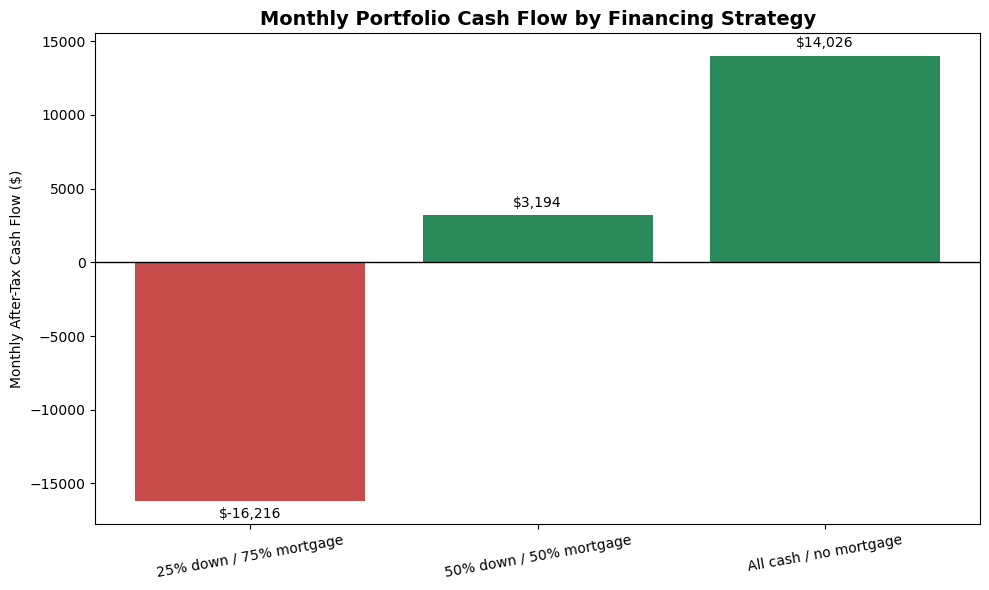

In [69]:
# ============================================================
# 18. VISUALIZE MONTHLY CASH FLOW BY FINANCING STRATEGY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

scenario_colors = np.where(
    national_results[
        "Portfolio Monthly Cash Flow"
    ] >= 0,
    "#2b8a5a",
    "#c94c4c",
)

bars = plt.bar(
    national_results[
        "Financing Scenario"
    ],
    national_results[
        "Portfolio Monthly Cash Flow"
    ],
    color=scenario_colors,
)

plt.axhline(
    0,
    color="black",
    linewidth=1,
)

plt.title(
    "Monthly Portfolio Cash Flow by Financing Strategy",
    fontsize=14,
    fontweight="bold",
)

plt.ylabel(
    "Monthly After-Tax Cash Flow ($)"
)

plt.xticks(
    rotation=10
)

plt.bar_label(
    bars,
    labels=[
        f"${value:,.0f}"
        for value in bars.datavalues
    ],
    padding=4,
)

plt.tight_layout()

plt.show()

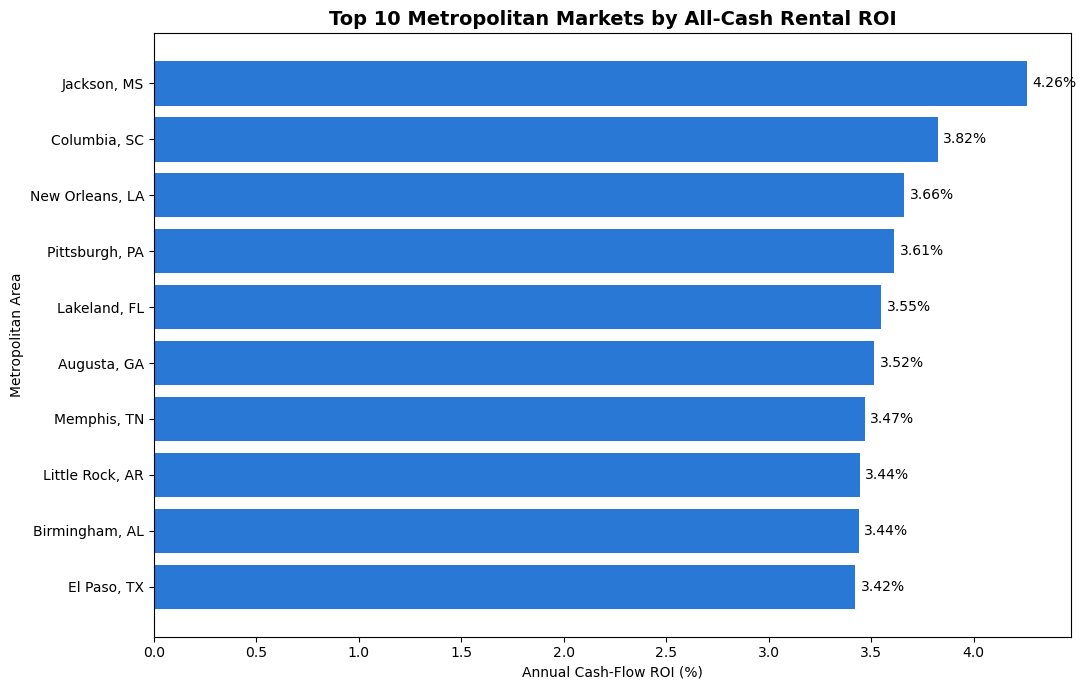

In [70]:
# ============================================================
# 19. VISUALIZE TOP 10 METRO AREAS BY RENTAL ROI
# ============================================================

plot_data = top_10_markets.sort_values(
    by="ROI - All Cash (%)",
    ascending=True,
)

plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    plot_data[
        "Metro Area"
    ],
    plot_data[
        "ROI - All Cash (%)"
    ],
    color="#2a78d6",
)

plt.title(
    "Top 10 Metropolitan Markets by All-Cash Rental ROI",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel(
    "Annual Cash-Flow ROI (%)"
)

plt.ylabel(
    "Metropolitan Area"
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in bars.datavalues
    ],
    padding=4,
)

plt.tight_layout()

plt.show()

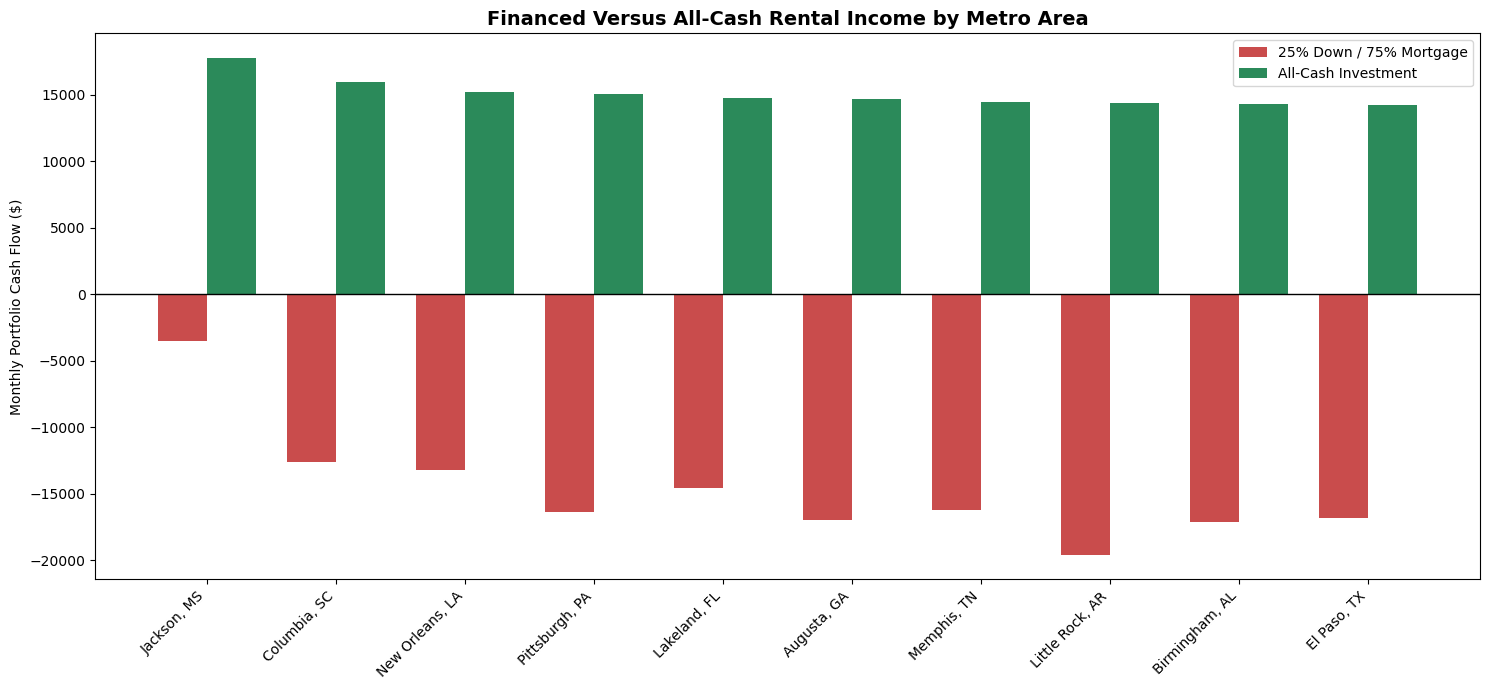

In [71]:
# ============================================================
# 20. VISUALIZE FINANCED VS. ALL-CASH MONTHLY RETURNS
# ============================================================

comparison_markets = top_10_markets.copy()

x = np.arange(
    len(comparison_markets)
)

bar_width = 0.38

plt.figure(
    figsize=(15, 7)
)

plt.bar(
    x - bar_width / 2,
    comparison_markets[
        "Monthly Cash Flow - 25% Down"
    ],
    width=bar_width,
    label="25% Down / 75% Mortgage",
    color="#c94c4c",
)

plt.bar(
    x + bar_width / 2,
    comparison_markets[
        "Monthly Cash Flow - All Cash"
    ],
    width=bar_width,
    label="All-Cash Investment",
    color="#2b8a5a",
)

plt.axhline(
    0,
    color="black",
    linewidth=1,
)

plt.xticks(
    x,
    comparison_markets[
        "Metro Area"
    ],
    rotation=45,
    ha="right",
)

plt.ylabel(
    "Monthly Portfolio Cash Flow ($)"
)

plt.title(
    "Financed Versus All-Cash Rental Income by Metro Area",
    fontsize=14,
    fontweight="bold",
)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

The analysis evaluated a $5 million rental-property investment across 737 metropolitan areas using July 2026 Zillow data. Financing strategy significantly influenced profitability:

25% down: 33 properties; monthly loss of **\$16,216**; annual ROI of −3.89%.
50% down: 21 properties; monthly profit of **\$3,194**; annual ROI of 0.77%.
All-cash purchases: 11 properties; monthly profit of **$14,026**; annual ROI of 3.37%.

Jackson, Mississippi, offered the highest estimated all-cash return of 4.26%, generating approximately $17,758 monthly. Other attractive markets included Columbia, South Carolina; New Orleans, Louisiana; and Pittsburgh, Pennsylvania. None of the 97 largest analyzed markets produced positive cash flow with 25% down.

### Conclusion

An all-cash or low-leverage strategy offers better rental profitability than heavily financed purchases under the assumed mortgage rate of 7.40%. Investing in affordable markets could generate approximately $14,000–$18,000 in monthly income and 3.4%–4.3% annual ROI. Actual results depend on local rents, property taxes, insurance, renovation costs, and market conditions.